# Probability Foundations — Part 3
## Computer Exercises: Sampling Distributions and Limits

This notebook solves the textbook computer exercises from Sections **4.1–4.5** of Chapter 4, *Sampling Distributions and Limits*.

For each exercise, the notebook adds:

- **Core concept** — what probability idea the exercise demonstrates;
- **Notation** — what the main symbols mean;
- **What to look for** — what the numerical result or plot is meant to show;
- **Implementation** — reproducible NumPy/SciPy code;
- **Interpretation** — what the result means probabilistically.

A fixed random seed is used so the results are reproducible.

### Parameterization conventions

- $\operatorname{Exponential}(\lambda)$ uses rate $\lambda$, so $E[X]=1/\lambda$.
- $N(\mu,\sigma^2)$ uses variance as the second parameter.
- $\operatorname{Geometric}(p)$ has support $\{1,2,\dots\}$ and mean $1/p$.
- $\operatorname{Gamma}(\alpha,\beta)$ uses shape $\alpha$ and rate $\beta$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import norm, gamma

rng = np.random.default_rng(20260827)

def summarize(x):
    return {
        "mean": float(np.mean(x)),
        "std": float(np.std(x, ddof=1))
    }

def mc_interval(sample_values, multiplier=3):
    sample_values = np.asarray(sample_values)
    estimate = sample_values.mean()
    se = sample_values.std(ddof=1) / np.sqrt(len(sample_values))
    return estimate, se, (estimate - multiplier * se, estimate + multiplier * se)

# Section 4.1 — Sampling Distributions

These exercises emphasize that a statistic such as a geometric mean or a maximum is itself a random variable. Repeating the sampling experiment reveals its **sampling distribution**.

## Exercise 4.1.10 — Sampling distribution of the geometric mean

From Example 4.1.1,

$$
P(X=1)=\frac12,\qquad
P(X=2)=\frac14,\qquad
P(X=3)=\frac14.
$$

For sample size $50$,

$$
Y_{50}=(X_1X_2\cdots X_{50})^{1/50}.
$$

Generate $N=10^3$ realizations of $Y_{50}$ and estimate its mean and standard deviation.

**Core concept:** sampling distribution of a nonlinear statistic.

**Notation:** $n=50$ is the number of observations used to make one $Y_{50}$; $N=1000$ is the number of repeated experiments.

**What to look for:** $Y_{50}$ changes from sample to sample, even though every sample comes from the same population.

In [2]:
N = 1_000
n = 50

x = rng.choice([1.0, 2.0, 3.0], size=(N, n), p=[0.5, 0.25, 0.25])

# log(Y_n) = mean(log(X_i))
y50 = np.exp(np.mean(np.log(x), axis=1))

result_4110 = summarize(y50)
result_4110

{'mean': 1.564475908762528, 'std': 0.10708419522882891}

The simulation estimates the center and spread of the sampling distribution of $Y_{50}$. The statistic is fairly concentrated because it is built from many independent observations.

## Exercise 4.1.11 — Distribution of a sample maximum

Let

$$
X_1,\dots,X_{10}\overset{\text{i.i.d.}}{\sim}N(0,1)
$$

and define

$$
Y=\max(X_1,\dots,X_{10}).
$$

Generate $N=10^3$ realizations of $Y$ and estimate its mean and standard deviation.

**Core concept:** sampling distribution of an order statistic.

**What to look for:** the maximum has a distribution very different from the original $N(0,1)$ distribution.

In [3]:
N = 1_000
n = 10

x = rng.normal(0, 1, size=(N, n))
sample_max = x.max(axis=1)

result_4111 = summarize(sample_max)
result_4111

{'mean': 1.5175892735560033, 'std': 0.5846413447969616}

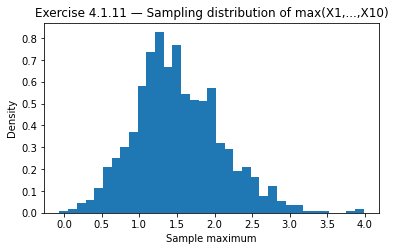

In [4]:
plt.figure(figsize=(6, 3.5))
plt.hist(sample_max, bins=35, density=True)
plt.title("Exercise 4.1.11 — Sampling distribution of max(X1,...,X10)")
plt.xlabel("Sample maximum")
plt.ylabel("Density")
plt.show()

The maximum is shifted to the right because it selects the largest observation from each group of ten. This illustrates how applying a function $h(X_1,\dots,X_n)$ creates a new sampling distribution.

# Section 4.2 — Convergence in Probability

Here we generate many independent replications at a **fixed sample size** $n$ and estimate probabilities of the form

$$
P(|M_n-\mu|\le\varepsilon).
$$

This is the simulation viewpoint behind convergence in probability and the Weak Law of Large Numbers.

## Exercise 4.2.12 — Exponential sample means

Let

$$
X_i\overset{\text{i.i.d.}}{\sim}\operatorname{Exponential}(5),
$$

so

$$
\mu=E[X_i]=\frac15=0.2.
$$

For $n=20$ and $n=50$, repeat the experiment $N=10^5$ times and estimate

$$
P(0.19\le M_n\le0.21).
$$

**Core concept:** convergence in probability of the sample mean.

**What to look for:** increasing $n$ should concentrate $M_n$ more strongly around $0.2$.

In [5]:
N = 100_000

def exponential_mean_interval_probability(n, rate=5, lower=0.19, upper=0.21):
    samples = rng.exponential(scale=1/rate, size=(N, n))
    means = samples.mean(axis=1)
    return np.mean((means >= lower) & (means <= upper))

p_exp_20 = exponential_mean_interval_probability(20)
p_exp_50 = exponential_mean_interval_probability(50)

p_exp_20, p_exp_50

(0.17589, 0.27595)

The probability increases as $n$ grows. This illustrates

$$
M_n\xrightarrow{P}\mu,
$$

so for every fixed $\varepsilon>0$,

$$
P(|M_n-\mu|<\varepsilon)\to1.
$$

## Exercise 4.2.13 — Poisson sample means

Let

$$
X_i\overset{\text{i.i.d.}}{\sim}\operatorname{Poisson}(7).
$$

Estimate

$$
P(6.99\le M_n\le7.01)
$$

for $n=20$ and $n=100$ using $N=10^5$ repeated samples.

**Core concept:** convergence in probability for a discrete parent distribution.

**What to look for:** the interval is extremely narrow, so discreteness matters, but concentration around $7$ still improves as $n$ increases.

In [6]:
def poisson_mean_interval_probability(n, lam=7, lower=6.99, upper=7.01):
    samples = rng.poisson(lam=lam, size=(N, n))
    means = samples.mean(axis=1)
    return np.mean((means >= lower) & (means <= upper))

p_pois_20 = poisson_mean_interval_probability(20)
p_pois_100 = poisson_mean_interval_probability(100)

p_pois_20, p_pois_100

(0.03338, 0.04482)

The theoretical property being illustrated is

$$
M_n\xrightarrow{P}7.
$$

Because a Poisson sample mean is discrete, the actual finite-sample probability can change in a step-like way as $n$ changes.

# Section 4.3 — Convergence with Probability 1

Now we generate **one long sequence**

$$
X_1,X_2,\dots
$$

and track the running means

$$
M_k=\frac{X_1+\cdots+X_k}{k}.
$$

This is the sample-path viewpoint behind the Strong Law of Large Numbers.

## Exercise 4.3.13 — Running means for Exponential(5)

Generate $10^5$ i.i.d. $\operatorname{Exponential}(5)$ observations.

**Core concept:** Strong Law of Large Numbers.

**Prediction:**

$$
M_n\xrightarrow{a.s.}\frac15=0.2.
$$

**What to look for:** large early fluctuations followed by increasingly small fluctuations around $0.2$.

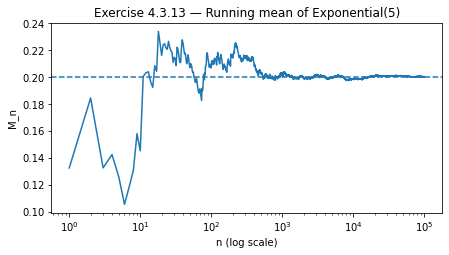

0.2003406265985184

In [7]:
n = 100_000
x = rng.exponential(scale=1/5, size=n)
running_mean_exp = np.cumsum(x) / np.arange(1, n + 1)

plt.figure(figsize=(7, 3.5))
plt.plot(np.arange(1, n + 1), running_mean_exp)
plt.axhline(0.2, linestyle="--")
plt.xscale("log")
plt.title("Exercise 4.3.13 — Running mean of Exponential(5)")
plt.xlabel("n (log scale)")
plt.ylabel("M_n")
plt.show()

running_mean_exp[-1]

The running mean approaches $0.2$. Typical sampling fluctuations shrink on the scale $1/\sqrt n$, while the Strong Law states the stronger sample-path convergence

$$
M_n\xrightarrow{a.s.}0.2.
$$

## Exercise 4.3.14 — Running means for Poisson(7)

Generate $10^5$ i.i.d. $\operatorname{Poisson}(7)$ observations.

**Prediction:**

$$
M_n\xrightarrow{a.s.}7.
$$

**Core concept:** Strong Law of Large Numbers for a discrete distribution.

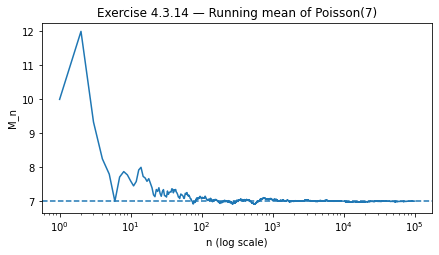

7.00569

In [8]:
x = rng.poisson(lam=7, size=n)
running_mean_pois = np.cumsum(x) / np.arange(1, n + 1)

plt.figure(figsize=(7, 3.5))
plt.plot(np.arange(1, n + 1), running_mean_pois)
plt.axhline(7, linestyle="--")
plt.xscale("log")
plt.title("Exercise 4.3.14 — Running mean of Poisson(7)")
plt.xlabel("n (log scale)")
plt.ylabel("M_n")
plt.show()

running_mean_pois[-1]

The individual observations remain integer-valued and noisy, but their running average settles near $7$.

## Exercise 4.3.15 — Running means for $N(-4,3)$

Interpret the textbook notation as mean $-4$ and variance $3$:

$$
X_i\sim N(-4,3).
$$

**Prediction:**

$$
M_n\xrightarrow{a.s.}-4.
$$

**Core concept:** Strong Law of Large Numbers in a normal model.

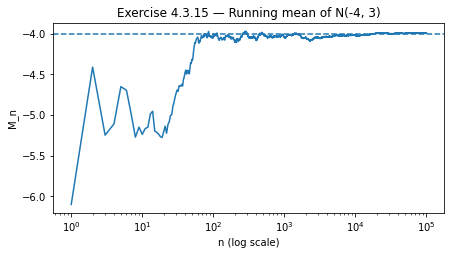

-3.992714294905033

In [9]:
x = rng.normal(loc=-4, scale=np.sqrt(3), size=n)
running_mean_norm = np.cumsum(x) / np.arange(1, n + 1)

plt.figure(figsize=(7, 3.5))
plt.plot(np.arange(1, n + 1), running_mean_norm)
plt.axhline(-4, linestyle="--")
plt.xscale("log")
plt.title("Exercise 4.3.15 — Running mean of N(-4, 3)")
plt.xlabel("n (log scale)")
plt.ylabel("M_n")
plt.show()

running_mean_norm[-1]

Here

$$
\operatorname{SD}(X_i)=\sqrt3,
$$

while

$$
\operatorname{SD}(M_n)=\sqrt{\frac3n}.
$$

The decreasing standard error explains the increasing stability of the running mean.

# Section 4.4 — Central Limit Theorem

For i.i.d. observations with mean $\mu$ and variance $\sigma^2$,

$$
M_n\approx N\left(\mu,\frac{\sigma^2}{n}\right)
$$

for sufficiently large $n$.

The following exercises compare Monte Carlo estimates with the corresponding CLT approximation.

## Exercise 4.4.15 — Exponential(3): simulation versus CLT

Let

$$
X_i\sim\operatorname{Exponential}(3),
\qquad
E[X_i]=\frac13,
\qquad
\operatorname{Var}(X_i)=\frac19.
$$

Estimate

$$
P\left(\frac16\le M_{20}\le\frac12\right)
$$

using $N=10^4$ samples, then compare with the CLT.

**Core concept:** normal approximation to a sample mean from a skewed parent distribution.

In [10]:
N_clt = 10_000
n = 20

x = rng.exponential(scale=1/3, size=(N_clt, n))
m = x.mean(axis=1)
mc_4415 = np.mean((m >= 1/6) & (m <= 1/2))

mu = 1/3
sigma = 1/3
se = sigma / np.sqrt(n)

z_low = (1/6 - mu) / se
z_high = (1/2 - mu) / se
clt_4415 = norm.cdf(z_high) - norm.cdf(z_low)

# Exact benchmark: n*M_n is Gamma(shape=n, rate=3).
exact_4415 = (
    gamma.cdf(n * (1/2), a=n, scale=1/3)
    - gamma.cdf(n * (1/6), a=n, scale=1/3)
)

mc_4415, clt_4415, exact_4415

(0.9737, 0.9746526813225318, 0.9746721895827523)

The Monte Carlo and CLT values should be close. The Gamma calculation is included as an exact benchmark, showing how accurate the CLT is in this particular finite-sample problem.

## Exercise 4.4.16 — Uniform[-20,10]: simulation versus CLT

For

$$
X_i\sim\operatorname{Uniform}[-20,10],
$$

we have

$$
\mu=-5,
\qquad
\sigma^2=75.
$$

Estimate

$$
P(M_{30}\le-5).
$$

**Core concept:** symmetry and the CLT.

**Prediction:** the exact probability is $0.5$ because the sample mean remains symmetric around $-5$.

In [11]:
n = 30

x = rng.uniform(-20, 10, size=(N_clt, n))
m = x.mean(axis=1)
mc_4416 = np.mean(m <= -5)

mu = -5
sigma = np.sqrt(75)
clt_4416 = norm.cdf((-5 - mu) / (sigma / np.sqrt(n)))

mc_4416, clt_4416

(0.5032, 0.5)

The CLT gives $0.5$, and the simulation should fluctuate near that value. Here symmetry gives an exact argument even before invoking the CLT.

## Exercise 4.4.17 — Geometric(1/4): simulation versus CLT

Let

$$
X_i\sim\operatorname{Geometric}\left(\frac14\right).
$$

Then

$$
\mu=4,
\qquad
\sigma^2=12.
$$

Estimate

$$
P(2.5\le M_{20}\le3.3)
$$

using $N=10^4$ samples and compare with the CLT.

**Core concept:** CLT approximation for a discrete, right-skewed distribution.

In [12]:
n = 20
p = 0.25

x = rng.geometric(p=p, size=(N_clt, n))
m = x.mean(axis=1)
mc_4417 = np.mean((m >= 2.5) & (m <= 3.3))

mu = 1 / p
sigma = np.sqrt((1 - p) / p**2)
se = sigma / np.sqrt(n)

z_low = (2.5 - mu) / se
z_high = (3.3 - mu) / se
clt_4417 = norm.cdf(z_high) - norm.cdf(z_low)

mc_4417, clt_4417

(0.1865, 0.15667452438897342)

Because the geometric distribution is skewed and $n=20$ is only moderate, the CLT approximation can show noticeable finite-sample error. This is a useful reminder that convergence in distribution is asymptotic, not exact.

## Exercise 4.4.18 — Histogram of means of $\log Z$

Let

$$
Z\sim\operatorname{Gamma}(4,1)
$$

and define

$$
X=\log Z.
$$

Generate $N=10^4$ samples of size $20$, calculate $M_{20}$ for each sample, and plot the sampling distribution.

**Core concept:** visual CLT approximation.

**What to look for:** the distribution of the sample mean should be more bell-shaped than the parent distribution.

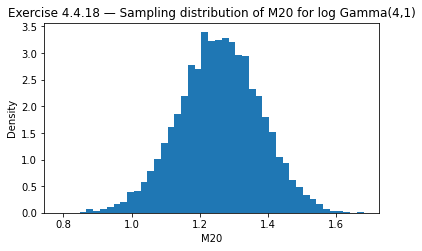

{'mean': 1.2573615176135053, 'std': 0.11910578712532577}

In [13]:
n = 20

z = rng.gamma(shape=4, scale=1, size=(N_clt, n))
x = np.log(z)
m_log_gamma = x.mean(axis=1)

plt.figure(figsize=(6, 3.5))
plt.hist(m_log_gamma, bins=45, density=True)
plt.title("Exercise 4.4.18 — Sampling distribution of M20 for log Gamma(4,1)")
plt.xlabel("M20")
plt.ylabel("Density")
plt.show()

summarize(m_log_gamma)

The histogram should look approximately normal. The CLT concerns the **sampling distribution of the mean**, not the requirement that the original observations themselves be normal.

## Exercise 4.4.19 — Rare-event binomial sample means

Let

$$
X_i\sim\operatorname{Binomial}(10,0.01)
$$

and generate $N=10^4$ values of $M_{20}$.

Here,

$$
E[X_i]=0.1,
\qquad
\operatorname{Var}(X_i)=0.099.
$$

**Core concept:** limitations of the finite-sample CLT approximation.

**What to look for:** the histogram remains discrete and noticeably right-skewed at $n=20$ because successes are rare.

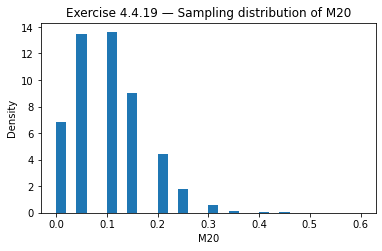

{'mean': 0.0994, 'std': 0.07027897205701958}

In [14]:
n = 20

x = rng.binomial(n=10, p=0.01, size=(N_clt, n))
m_binom = x.mean(axis=1)

plt.figure(figsize=(6, 3.5))
plt.hist(m_binom, bins=30, density=True)
plt.title("Exercise 4.4.19 — Sampling distribution of M20")
plt.xlabel("M20")
plt.ylabel("Density")
plt.show()

summarize(m_binom)

Since

$$
\sum_{i=1}^{20}X_i
\sim
\operatorname{Binomial}(200,0.01),
$$

the expected total number of successes is only

$$
200(0.01)=2.
$$

That explains why the distribution remains strongly discrete and skewed. It also shows why there is no universal sample-size threshold for a good CLT approximation.

# Section 4.5 — Monte Carlo Approximations

The common pattern is

$$
\text{target quantity}=E[T]
\approx
\frac1n\sum_{i=1}^nT_i.
$$

The Law of Large Numbers justifies the approximation. The estimated standard error is

$$
\widehat{\operatorname{SE}}
=
\frac{S_T}{\sqrt n}.
$$

We use the textbook-style rough interval

$$
\widehat\theta\pm3\widehat{\operatorname{SE}}.
$$

## Exercise 4.5.14 — Monte Carlo integration on $[0,1]$

Approximate

$$
I=
\int_0^1\cos(x^3)\sin(x^4)\,dx.
$$

If

$$
U\sim\operatorname{Uniform}(0,1),
$$

then

$$
I=E[\cos(U^3)\sin(U^4)].
$$

**Core concept:** rewrite a deterministic integral as an expectation.

In [15]:
n_mc = 100_000

u = rng.uniform(0, 1, size=n_mc)
t = np.cos(u**3) * np.sin(u**4)

estimate_4514, se_4514, interval_4514 = mc_interval(t)
estimate_4514, se_4514, interval_4514

(0.14872731176843706,
 0.0005375156538146442,
 (0.14711476480699312, 0.150339858729881))

The uncertainty shrinks at rate $1/\sqrt n$. The Monte Carlo sample standard deviation measures how noisy the transformed variable $T$ is.

## Exercise 4.5.15 — Monte Carlo integration with exponential sampling

Approximate

$$
I=
\int_0^\infty25\cos(x^4)e^{-25x}\,dx.
$$

Since the density of

$$
X\sim\operatorname{Exponential}(25)
$$

is

$$
f_X(x)=25e^{-25x},
$$

we obtain

$$
I=E[\cos(X^4)].
$$

**Core concept:** choose a sampling distribution whose density matches the integral.

In [16]:
x = rng.exponential(scale=1/25, size=n_mc)
t = np.cos(x**4)

estimate_4515, se_4515, interval_4515 = mc_interval(t)
estimate_4515, se_4515, interval_4515

(0.9999998460380042,
 2.655609014032725e-08,
 (0.9999997663697338, 0.9999999257062746))

This reformulation is efficient because the exponential density absorbs the full factor $25e^{-25x}$.

## Exercise 4.5.16 — Monte Carlo approximation of an infinite sum

Approximate

$$
S=
\sum_{j=0}^{\infty}(j^2+3)^{-5}5^{-j}.
$$

Choose $J$ on $\{0,1,2,\dots\}$ with

$$
P(J=j)=\frac45\left(\frac15\right)^j.
$$

Then

$$
5^{-j}
=
\frac54P(J=j),
$$

so

$$
S
=
\frac54E[(J^2+3)^{-5}].
$$

**Core concept:** interpret summation weights as a probability mass function and convert an infinite sum into an expectation.

In [17]:
# NumPy geometric has support {1,2,...}; subtract 1.
j = rng.geometric(p=4/5, size=n_mc) - 1
t = (5/4) * (j**2 + 3.0) ** (-5)

estimate_4516, se_4516, interval_4516 = mc_interval(t)
estimate_4516, se_4516, interval_4516

(0.0043159066921171375,
 5.290143315291989e-06,
 (0.004300036262171261, 0.0043317771220630135))

The same expectation-to-average principle works for discrete sums just as it does for continuous integrals.

## Exercise 4.5.17 — Probability estimation with an indicator

Let

$$
X\sim N(0,1)
$$

and approximate

$$
P(X^2-3X+2\ge0).
$$

Set

$$
T=I(X^2-3X+2\ge0).
$$

Then

$$
E[T]
=
P(X^2-3X+2\ge0).
$$

**Core concept:** probability estimation is Bernoulli Monte Carlo.

Since $T$ is Bernoulli,

$$
\widehat{\operatorname{SE}}
=
\sqrt{\frac{\widehat p(1-\widehat p)}{n}}.
$$

In [18]:
x = rng.normal(0, 1, size=n_mc)
t = (x**2 - 3*x + 2 >= 0).astype(float)

estimate_4517, se_4517, interval_4517 = mc_interval(t)

# Exact benchmark:
# (x-1)(x-2) >= 0 iff X <= 1 or X >= 2.
exact_4517 = norm.cdf(1) + (1 - norm.cdf(2))

estimate_4517, se_4517, interval_4517, exact_4517

(0.86414,
 0.001083527731220315,
 (0.8608894168063391, 0.8673905831936609),
 0.8640948780167221)

This is the same Bernoulli structure used when estimating a CDF:

$$
I(\text{event})\in\{0,1\},
$$

and the event probability is the expectation of that indicator.

# Final comparison — what the exercises represent

| Section | Main computational object | Core concept |
|---|---|---|
| 4.1 | Repeated values of a statistic | Sampling distributions |
| 4.2 | Many replications at fixed $n$ | Convergence in probability / WLLN |
| 4.3 | One long sequence of running means | Almost-sure convergence / SLLN |
| 4.4 | Distribution of sample means | CLT and normal approximation |
| 4.5 | Averages of simulated transforms | Monte Carlo and LLN |

A recurring notation distinction is:

- $n$: number of original observations used to construct one statistic or Monte Carlo average;
- $N$: number of independent replications used to study a sampling distribution.

The computational story of the chapter is

$$
\boxed{
\text{random sampling}
\longrightarrow
\text{sample average}
\longrightarrow
\text{convergence / approximation}
}
$$

with the LLN explaining **why averages stabilize**, the CLT explaining **how their error behaves**, and Monte Carlo turning these facts into practical algorithms.